# Network Analysis: Communication Patterns and Bottleneck Hypothesis

**Hypothesis**: Is inter-device communication a bottleneck for inference latency?

This notebook:
1. Loads and parses network telemetry and latency traces from all experiments
2. Characterizes communication patterns (volume, burstiness, activity, topology)
3. Correlates communication signals with latency to test the bottleneck hypothesis


## Setup


In [1]:
import os
import re
import math
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid', context='talk')

DATA_ROOT = Path('../data')
TRACE_ROOT = DATA_ROOT / 'data_compsys' / 'final' / 'trace'
OUTPUT_DIR = DATA_ROOT / 'processed'
IMAGES_DIR = DATA_ROOT / 'figures' / '04_network'

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
IMAGES_DIR.mkdir(parents=True, exist_ok=True)

experiment_paths = sorted([p for p in TRACE_ROOT.iterdir() if p.is_dir()])
print(f'Found {len(experiment_paths)} experiments')


Found 14 experiments


## Helpers

Os nomes brutos de experimentos e nós seguem uma convenção compacta usada pelos scripts de coleta
(por exemplo, `N2_poti_TP_long_r1_790072` ou `poti1`).

- **`format_node_name`**: formata nomes de nó como `POTI-1`.
- **`format_experiment_name`**: produz rótulos de duas linhas adequados para eixos de gráficos.

Ambas tratam entradas inesperadas retornando o valor original em vez de lançar exceções.


In [2]:
COMM_THRESHOLD = 10.0  # kB/s
TYPE_ORDER = {'tp': 0, 'pp': 1, 'none': 2}


def parse_exp_name(name):
    parts = name.split('_')
    return {
        'exp_name': name,
        'cluster_size': int(parts[0][1:]),
        'cluster': parts[1],
        'parallelism': parts[2],
        'seqlen': parts[3],
    }


def format_node_name(node):
    if not isinstance(node, str):
        return str(node).upper()
    match = re.match(r'([a-zA-Z]+)(\d+)', node)
    return f'{match.group(1).upper()}-{match.group(2)}' if match else node.upper()


def format_experiment_name(name):
    if not isinstance(name, str) or pd.isna(name):
        return 'Unknown Experiment'
    parts = name.split('_')
    if len(parts) < 4:
        return name
    try:
        n_nodes = parts[0][1:]
        system = parts[1].upper()
        strategy = parts[2]
        length = parts[3]
        node_text = f'{n_nodes} Node' if n_nodes == '1' else f'{n_nodes} Nodes'
        strat_map = {'none': 'No Comm', 'pp': 'Pipeline Parallel', 'tp': 'Tensor Parallel',
                     'PP': 'Pipeline Parallel', 'TP': 'Tensor Parallel'}
        strategy_text = strat_map.get(strategy, strategy.upper())
        len_text = 'Short' if length.lower() == 'short' else 'Long'
        return f'{node_text} {system}\n{strategy_text} ({len_text})'
    except Exception:
        return name


def get_experiment_type(exp_name):
    name = exp_name.lower()
    if 'tp' in name:
        return 'tp'
    if 'pp' in name:
        return 'pp'
    return 'none'


def experiment_sort_key(exp_name):
    m = parse_exp_name(exp_name)
    strategy_rank = TYPE_ORDER.get(m['parallelism'].lower(), 99)
    workload_rank = {'short': 0, 'long': 1}.get(m['seqlen'], 99)
    return (m['cluster_size'], m['cluster'], strategy_rank, workload_rank)


def save_fig(fig, filename):
    fig.savefig(IMAGES_DIR / filename, dpi=150, bbox_inches='tight')
    plt.show()


def second_level_node_df(exp_df):
    return (
        exp_df.assign(timestamp=pd.to_datetime(exp_df['timestamp']))
        .groupby(['node_name', pd.Grouper(key='timestamp', freq='1s')])['total_kB_s']
        .sum()
        .reset_index()
    )


def trim_idle_tails_and_normalize_time(exp_df, threshold_kB_s=500.0, margin_seconds=10):
    activity = exp_df.groupby('timestamp')['total_kB_s'].sum().sort_index()
    active_mask = activity > threshold_kB_s
    exp_df = exp_df.copy()
    if active_mask.any():
        start_time = activity.index[active_mask][0] - pd.Timedelta(seconds=margin_seconds)
        end_time = activity.index[active_mask][-1] + pd.Timedelta(seconds=margin_seconds)
        exp_df = exp_df[
            (exp_df['timestamp'] >= start_time) & (exp_df['timestamp'] <= end_time)
        ].copy()
    exp_df['t'] = (exp_df['timestamp'] - exp_df['timestamp'].min()).dt.total_seconds()
    return exp_df


ordered_experiments = sorted([p.name for p in experiment_paths], key=experiment_sort_key)


## Load and Normalize Telemetry

Os arquivos `network_telemetry.csv` têm um formato de colunas separadas por espaço, não um CSV convencional.
A função `load_network_csv` faz o parsing linha a linha, validando que cada linha tem exatamente 13 campos
antes de extrair as métricas de interesse. Resultado salvo em `data/processed/network_timeseries.csv`.


In [3]:
def find_network_files(experiment_path):
    files = []
    for root, _, filenames in os.walk(experiment_path):
        if 'network_telemetry.csv' in filenames:
            files.append(Path(root) / 'network_telemetry.csv')
    return files


def load_network_csv(path):
    rows = []
    with open(path, 'r') as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) != 13:
                continue
            rows.append({
                'timestamp': pd.to_datetime(f'{parts[0]} {parts[1]}'),
                'interface': parts[4],
                'rx_packets_s': float(parts[5]),
                'tx_packets_s': float(parts[6]),
                'rx_kB_s': float(parts[7]),
                'tx_kB_s': float(parts[8]),
                'ifutil_pct': float(parts[12]),
            })
    return pd.DataFrame(rows)


network_rows = []
for exp_path in experiment_paths:
    for net_file in find_network_files(exp_path):
        node_name = net_file.parent.name
        try:
            df = load_network_csv(net_file)
            df['experiment_name'] = exp_path.name
            df['node_name'] = node_name
            df['total_kB_s'] = df['rx_kB_s'] + df['tx_kB_s']
            network_rows.append(df)
        except Exception as e:
            print(f'Error loading {net_file}: {e}')

if network_rows:
    network_ts_df = pd.concat(network_rows, ignore_index=True)
    network_ts_df.to_csv(OUTPUT_DIR / 'network_timeseries.csv', index=False)
    print(f'Loaded {network_ts_df.shape[0]} rows from {len(experiment_paths)} experiments')
    network_ts_df.head()
else:
    print('Warning: No network_telemetry.csv files found in experiments.')
    print('Available files in first experiment:', list(experiment_paths[0].rglob('*'))[:5] if experiment_paths else 'No experiments found')

Loaded 15886 rows from 14 experiments


In [4]:
summary_rows = []
for (experiment_name, node_name), group in network_ts_df.groupby(['experiment_name', 'node_name']):
    summary_rows.append({
        'experiment_name': experiment_name,
        'node_name': node_name,
        'rx_avg_kB_s': group['rx_kB_s'].mean(),
        'tx_avg_kB_s': group['tx_kB_s'].mean(),
        'total_avg_kB_s': group['total_kB_s'].mean(),
        'rx_peak_kB_s': group['rx_kB_s'].max(),
        'tx_peak_kB_s': group['tx_kB_s'].max(),
        'total_peak_kB_s': group['total_kB_s'].max(),
        'ifutil_avg_pct': group['ifutil_pct'].mean(),
        'ifutil_peak_pct': group['ifutil_pct'].max(),
    })
network_node_summary_df = pd.DataFrame(summary_rows)
network_node_summary_df.head()


,experiment_name,node_name,rx_avg_kB_s,tx_avg_kB_s,total_avg_kB_s,rx_peak_kB_s,tx_peak_kB_s,total_peak_kB_s,ifutil_avg_pct,ifutil_peak_pct
0,N1_tupi_none_long_r1_790478,tupi2,25.992500,1.120318,27.112818,4094.37,52.60,4146.97,0.021409,3.35
1,N1_tupi_none_short_r1_790477,tupi2,0.695505,0.578139,1.273644,38.26,11.52,49.78,0.000713,0.03
2,N2_poti_PP_long_r1_790071,poti1,30.762448,354.280280,385.042727,420.00,2603.09,3017.41,0.293403,2.13
3,N2_poti_PP_long_r1_790071,poti2,336.014670,27.484648,363.499318,5276.29,175.13,5402.17,0.277804,4.32
4,N2_poti_PP_short_r1_790074,poti3,46.111628,588.400853,634.512481,430.83,2602.87,2854.30,0.484186,2.13


## Load Latency Metrics

Extracts TTFT and inter-token latency from `profile_export_aiperf.csv` (head node only).


In [5]:
def extract_latency_metrics(csv_path):
    metrics = {}
    try:
        with open(csv_path, 'r') as f:
            for line in f:
                line = line.strip()
                if not line or ',' not in line:
                    continue
                parts = [p.strip() for p in line.split(',')]
                if len(parts) < 2:
                    continue
                metric_name = parts[0].lower()
                if 'ttft' in metric_name or 'time to first token' in metric_name:
                    try:
                        metrics['TTFT_avg_ms'] = float(parts[1])
                    except Exception:
                        pass
                    if len(parts) > 13:
                        try:
                            metrics['TTFT_p99_ms'] = float(parts[13])
                        except Exception:
                            pass
                if 'inter' in metric_name and 'token' in metric_name:
                    try:
                        metrics['inter_token_avg_ms'] = float(parts[1])
                    except Exception:
                        pass
                    if len(parts) > 13:
                        try:
                            metrics['inter_token_p99_ms'] = float(parts[13])
                        except Exception:
                            pass
    except Exception:
        pass
    return metrics


def aggregate_latency_signals(exp_path):
    for node_dir in sorted(exp_path.iterdir()):
        if not node_dir.is_dir():
            continue
        profile_csv = node_dir / 'profile_export_aiperf.csv'
        if profile_csv.exists():
            signals = extract_latency_metrics(profile_csv)
            if signals:
                return signals
    return {}


## Build Experiment Summary

Combines network and latency signals per experiment. Computes latency overhead relative to the
N1 (single-node) baseline per `(cluster, seqlen)` group.


In [6]:
def aggregate_network_signals(exp_name):
    tp = network_ts_df[network_ts_df['experiment_name'] == exp_name]['total_kB_s'].dropna().values
    if len(tp) == 0:
        return {}
    return {
        'total_comm_avg_kB_s': float(np.mean(tp)),
        'total_comm_peak_kB_s': float(np.max(tp)),
        'active_comm_fraction': float(np.mean(tp > COMM_THRESHOLD)),
        'total_volume_GB': float(np.sum(tp) / 1024 / 1024),
        'burstiness_cv': float(np.std(tp) / np.mean(tp)) if np.mean(tp) > 0 else None,
    }


all_signals = []
for exp_path in experiment_paths:
    meta = parse_exp_name(exp_path.name)
    comm = aggregate_network_signals(exp_path.name)
    latency = aggregate_latency_signals(exp_path)
    all_signals.append({**meta, **comm, **latency})

summary_df = pd.DataFrame(all_signals)

overhead_rows = []
for (cluster, seqlen), group in summary_df.groupby(['cluster', 'seqlen']):
    n1 = group[group['cluster_size'] == 1]
    baseline_ttft = n1.iloc[0].get('TTFT_avg_ms') if len(n1) > 0 else None
    baseline_inter = n1.iloc[0].get('inter_token_avg_ms') if len(n1) > 0 else None
    for _, row in group.iterrows():
        row_copy = row.copy()
        if baseline_ttft and pd.notna(baseline_ttft) and pd.notna(row.get('TTFT_avg_ms')):
            row_copy['TTFT_overhead_pct'] = 100 * (row['TTFT_avg_ms'] - baseline_ttft) / baseline_ttft
        if baseline_inter and pd.notna(baseline_inter) and pd.notna(row.get('inter_token_avg_ms')):
            row_copy['inter_token_overhead_pct'] = 100 * (row['inter_token_avg_ms'] - baseline_inter) / baseline_inter
        overhead_rows.append(row_copy)

summary_df = pd.DataFrame(overhead_rows)
summary_df.to_csv(OUTPUT_DIR / 'summary_network.csv', index=False)
print(f'Summary: {summary_df.shape}')
summary_df[['exp_name', 'cluster_size', 'parallelism', 'seqlen', 'TTFT_avg_ms', 'total_comm_avg_kB_s']].head(10)


Summary: (14, 16)


,exp_name,cluster_size,parallelism,seqlen,TTFT_avg_ms,total_comm_avg_kB_s
2,N2_poti_PP_long_r1_790071,2,PP,long,80.33,373.791214
4,N2_poti_TP_long_r1_790072,2,TP,long,547.11,19017.157540
10,N4_poti_PP_long_r1_790467,4,PP,long,119.89,856.721918
12,N4_poti_TP_long_r1_790077,4,TP,long,789.06,13498.227757
3,N2_poti_PP_short_r1_790074,2,PP,short,79.77,585.251306
5,N2_poti_TP_short_r1_790073,2,TP,short,552.49,39543.187927
11,N4_poti_PP_short_r1_796873,4,PP,short,117.55,383.425983
13,N4_poti_TP_short_r1_790075,4,TP,short,789.88,13311.102554
0,N1_tupi_none_long_r1_790478,1,none,long,31.94,27.112818
6,N2_tupi_PP_long_r1_796872,2,PP,long,238.14,1952.928663


## Network Throughput

Aqui comparamos os experimentos entre si em termos de throughput médio de rede.
O gráfico de barras ordena os experimentos pelo throughput médio agregado (RX + TX).
O heatmap detalha a contribuição de cada nó individualmente.
É possível ver que os experimentos que usam Tensor Parallel utilizam muito mais a rede que os outros.


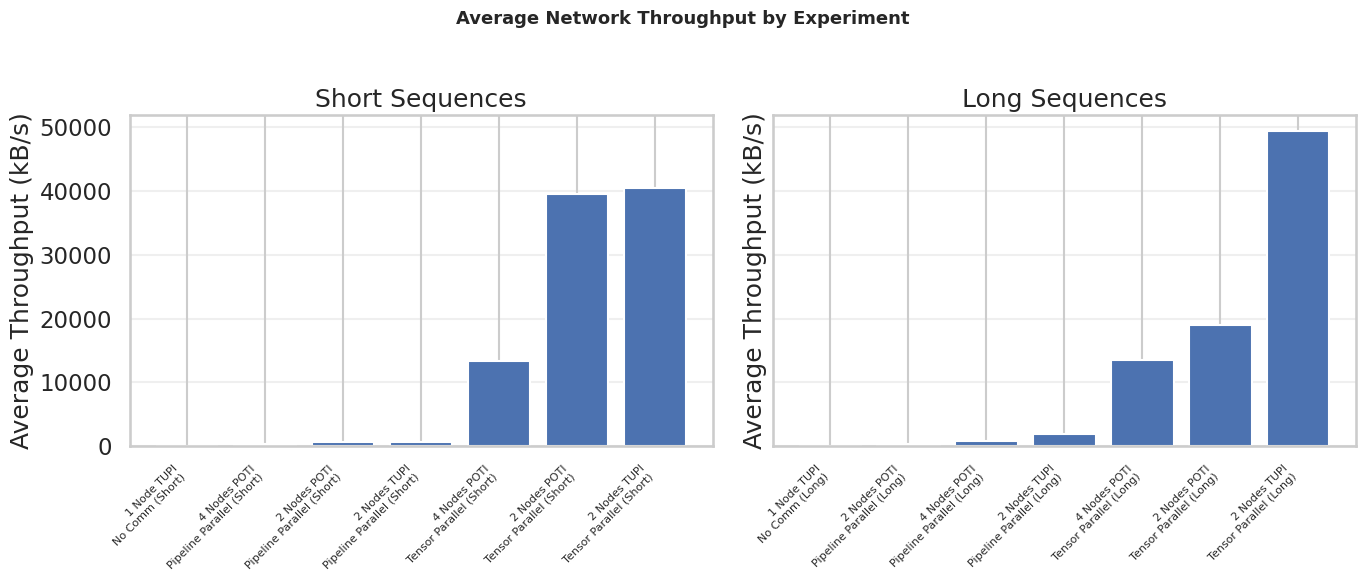

In [7]:
# Average network throughput by experiment — separated by sequence length

net_agg = network_ts_df.groupby('experiment_name').agg(
    rx_kB_s=('rx_kB_s', 'mean'),
    tx_kB_s=('tx_kB_s', 'mean'),
).reset_index()

net_agg['experiment_avg_kB_s'] = net_agg['rx_kB_s'] + net_agg['tx_kB_s']
net_agg['experiment_label'] = net_agg['experiment_name'].apply(format_experiment_name)
net_agg['seqlen'] = net_agg['experiment_name'].apply(lambda x: parse_exp_name(x)['seqlen'])

fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

for ax, seqlen in zip(axes, ['short', 'long']):
    subset = net_agg[net_agg['seqlen'] == seqlen].sort_values('experiment_avg_kB_s').reset_index(drop=True)
    if len(subset) > 0:
        ax.bar(range(len(subset)), subset['experiment_avg_kB_s'])
        ax.set_xticks(range(len(subset)))
        ax.set_xticklabels(subset['experiment_label'], rotation=45, ha='right', fontsize=8)
        ax.set_ylabel('Average Throughput (kB/s)')
        ax.set_title(f'{seqlen.capitalize()} Sequences')
        ax.grid(axis='y', alpha=0.3)

fig.suptitle('Average Network Throughput by Experiment', fontsize=13, fontweight='bold')
fig.tight_layout(rect=[0, 0, 1, 0.97])
save_fig(fig, 'network_throughput_by_experiment.png')

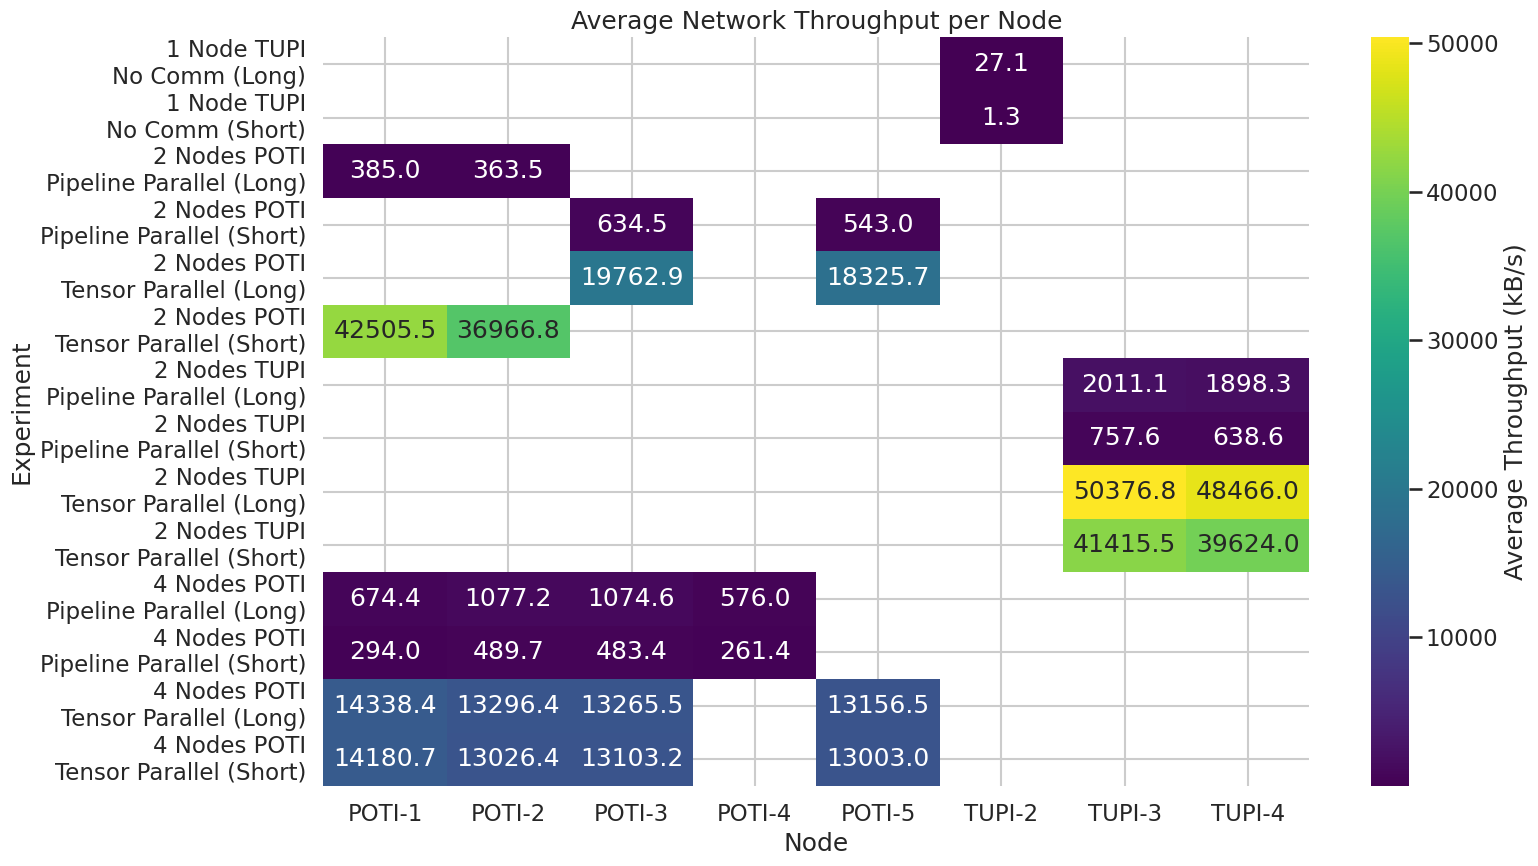

In [8]:
# Average network throughput per node (heatmap)

pivot = (
    network_ts_df
    .assign(
        experiment_label=lambda d: d['experiment_name'].apply(format_experiment_name),
        node_label=lambda d: d['node_name'].apply(format_node_name),
    )
    .groupby(['experiment_label', 'node_label'])['total_kB_s']
    .mean()
    .unstack()
)

fig, ax = plt.subplots(figsize=(16, 9))

sns.heatmap(
    pivot,
    annot=True,
    fmt='.1f',
    cmap='viridis',
    cbar_kws={'label': 'Average Throughput (kB/s)'},
    ax=ax,
)

ax.set_title('Average Network Throughput per Node')
ax.set_xlabel('Node')
ax.set_ylabel('Experiment')

fig.tight_layout()
save_fig(fig, 'network_throughput_per_node.png')

## Throughput Over Time

No pipeline parallelism, o tráfego concentra-se em fases definidas (troca de ativações entre estágios),
produzindo um perfil mais regular. O tensor parallelism apresenta comunicação distribuída ao longo
da execução (all-reduce/all-gather), gerando maior irregularidade e picos mais pronunciados.


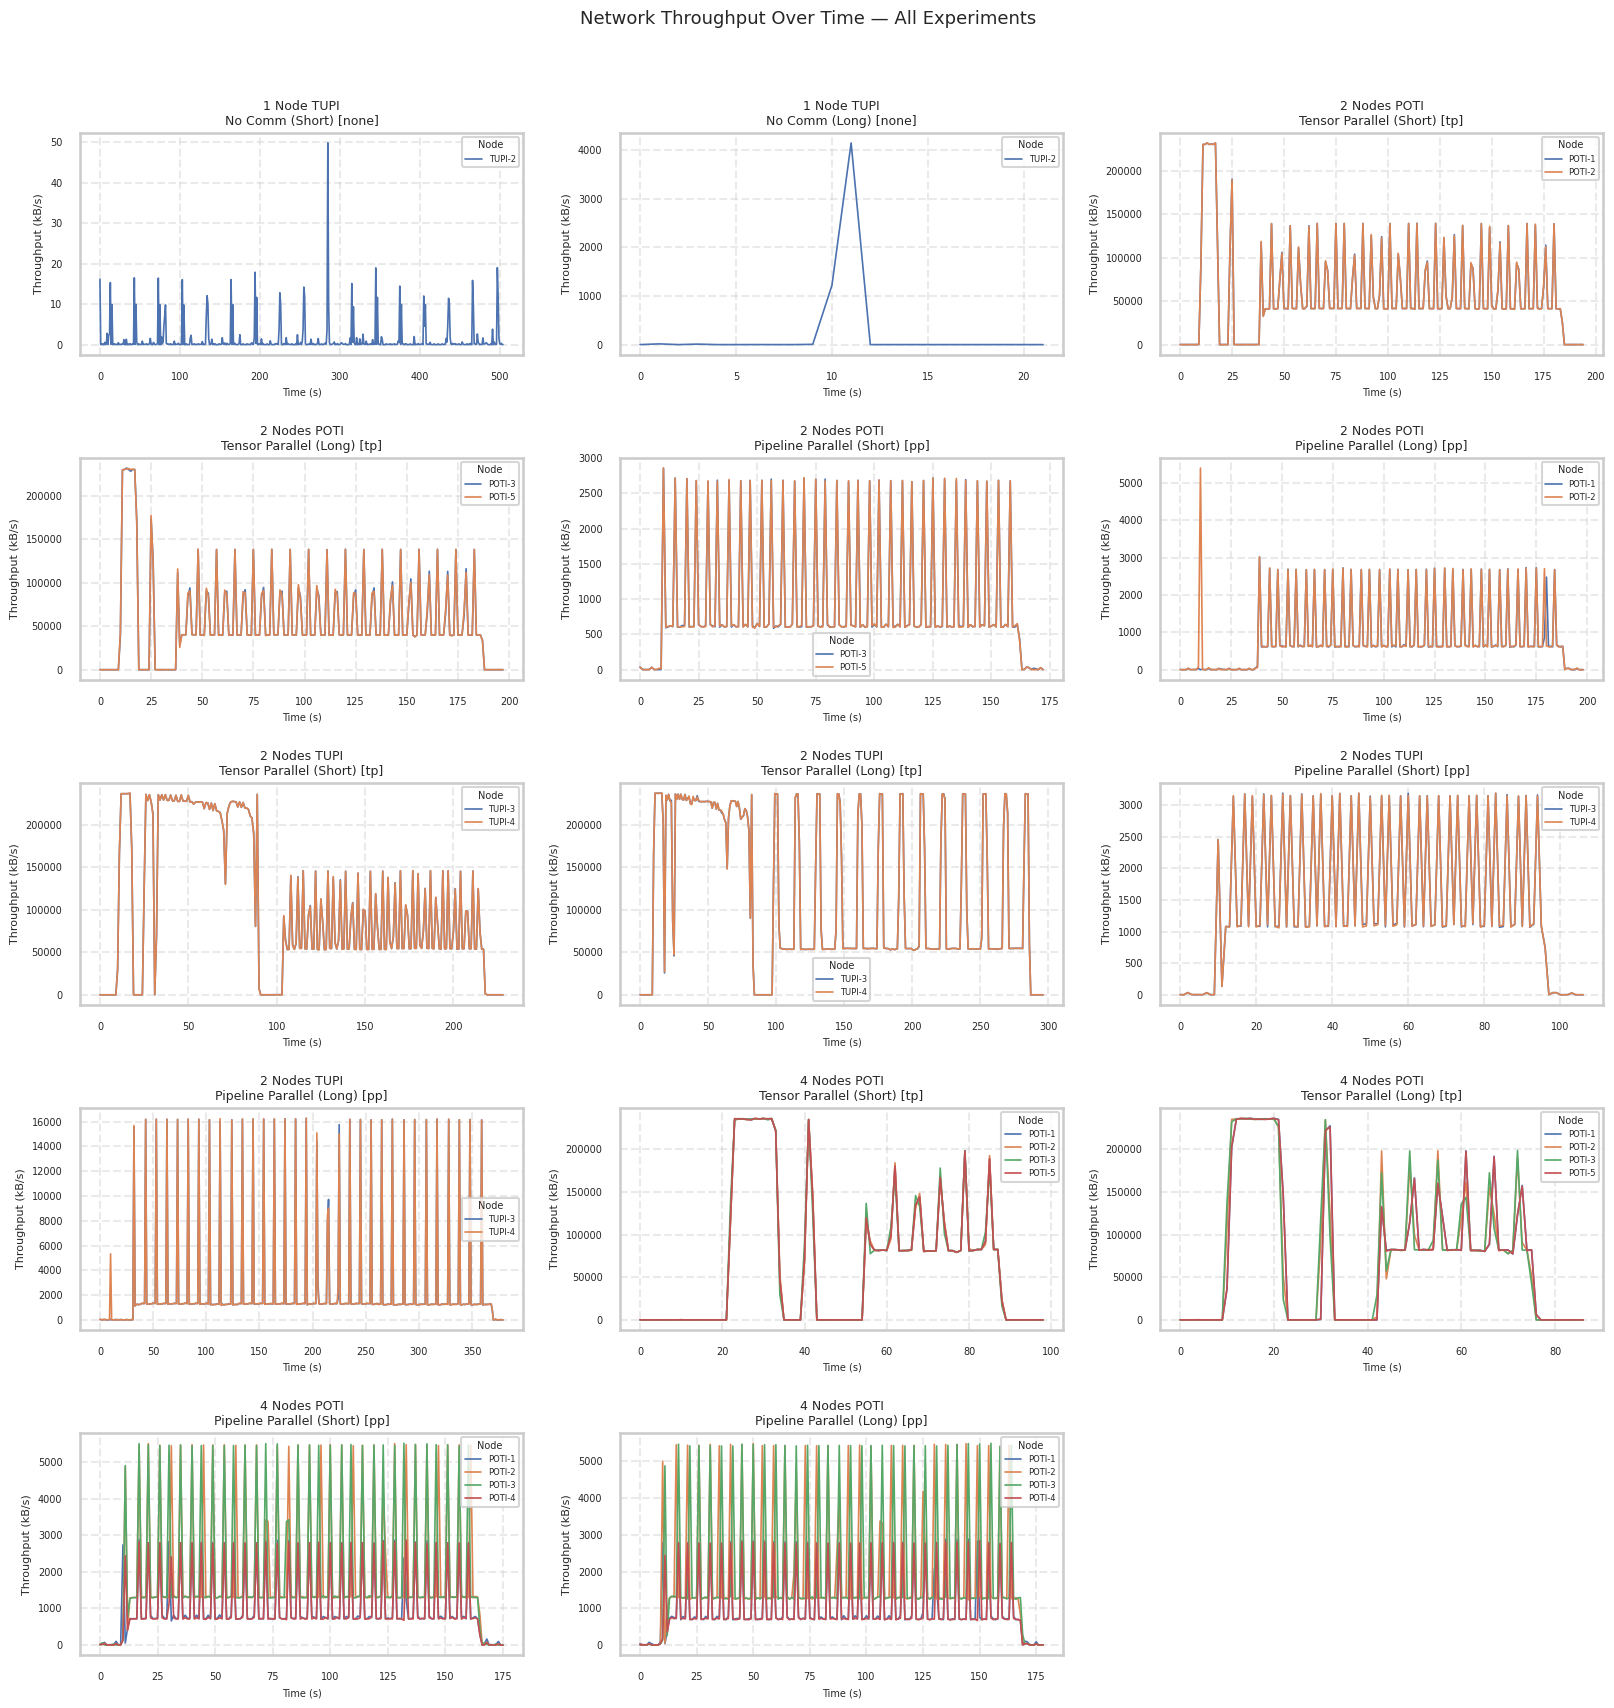

In [9]:
n_exp = len(ordered_experiments)
n_cols = 3
n_rows = math.ceil(n_exp / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5.5 * n_cols, 3.5 * n_rows), squeeze=False)
axes_flat = axes.flatten()

for ax, exp_name in zip(axes_flat, ordered_experiments):
    exp_df = network_ts_df[network_ts_df['experiment_name'] == exp_name].copy()
    exp_df = trim_idle_tails_and_normalize_time(exp_df)
    for node in sorted(exp_df['node_name'].unique()):
        node_df = exp_df[exp_df['node_name'] == node].sort_values('t')
        ax.plot(node_df['t'], node_df['total_kB_s'], linewidth=1.2, label=format_node_name(node))
    ax.set_title(f"{format_experiment_name(exp_name)} [{get_experiment_type(exp_name)}]", fontsize=9)
    ax.set_xlabel('Time (s)', fontsize=7)
    ax.set_ylabel('Throughput (kB/s)', fontsize=8)
    ax.tick_params(labelsize=7)
    ax.grid(True, linestyle='--', alpha=0.4)
    ax.legend(fontsize=6, title='Node', title_fontsize=7)

for ax in axes_flat[n_exp:]:
    ax.set_visible(False)

fig.suptitle('Network Throughput Over Time — All Experiments', fontsize=13)
fig.tight_layout(rect=[0, 0, 1, 0.97])
save_fig(fig, 'all_experiments_network_throughput.png')


### Cumulative Communication Volume

Revela *quando* o tráfego ocorre: crescimento linear indica comunicação distribuída uniformemente;
crescimento em degraus indica rajadas pontuais.


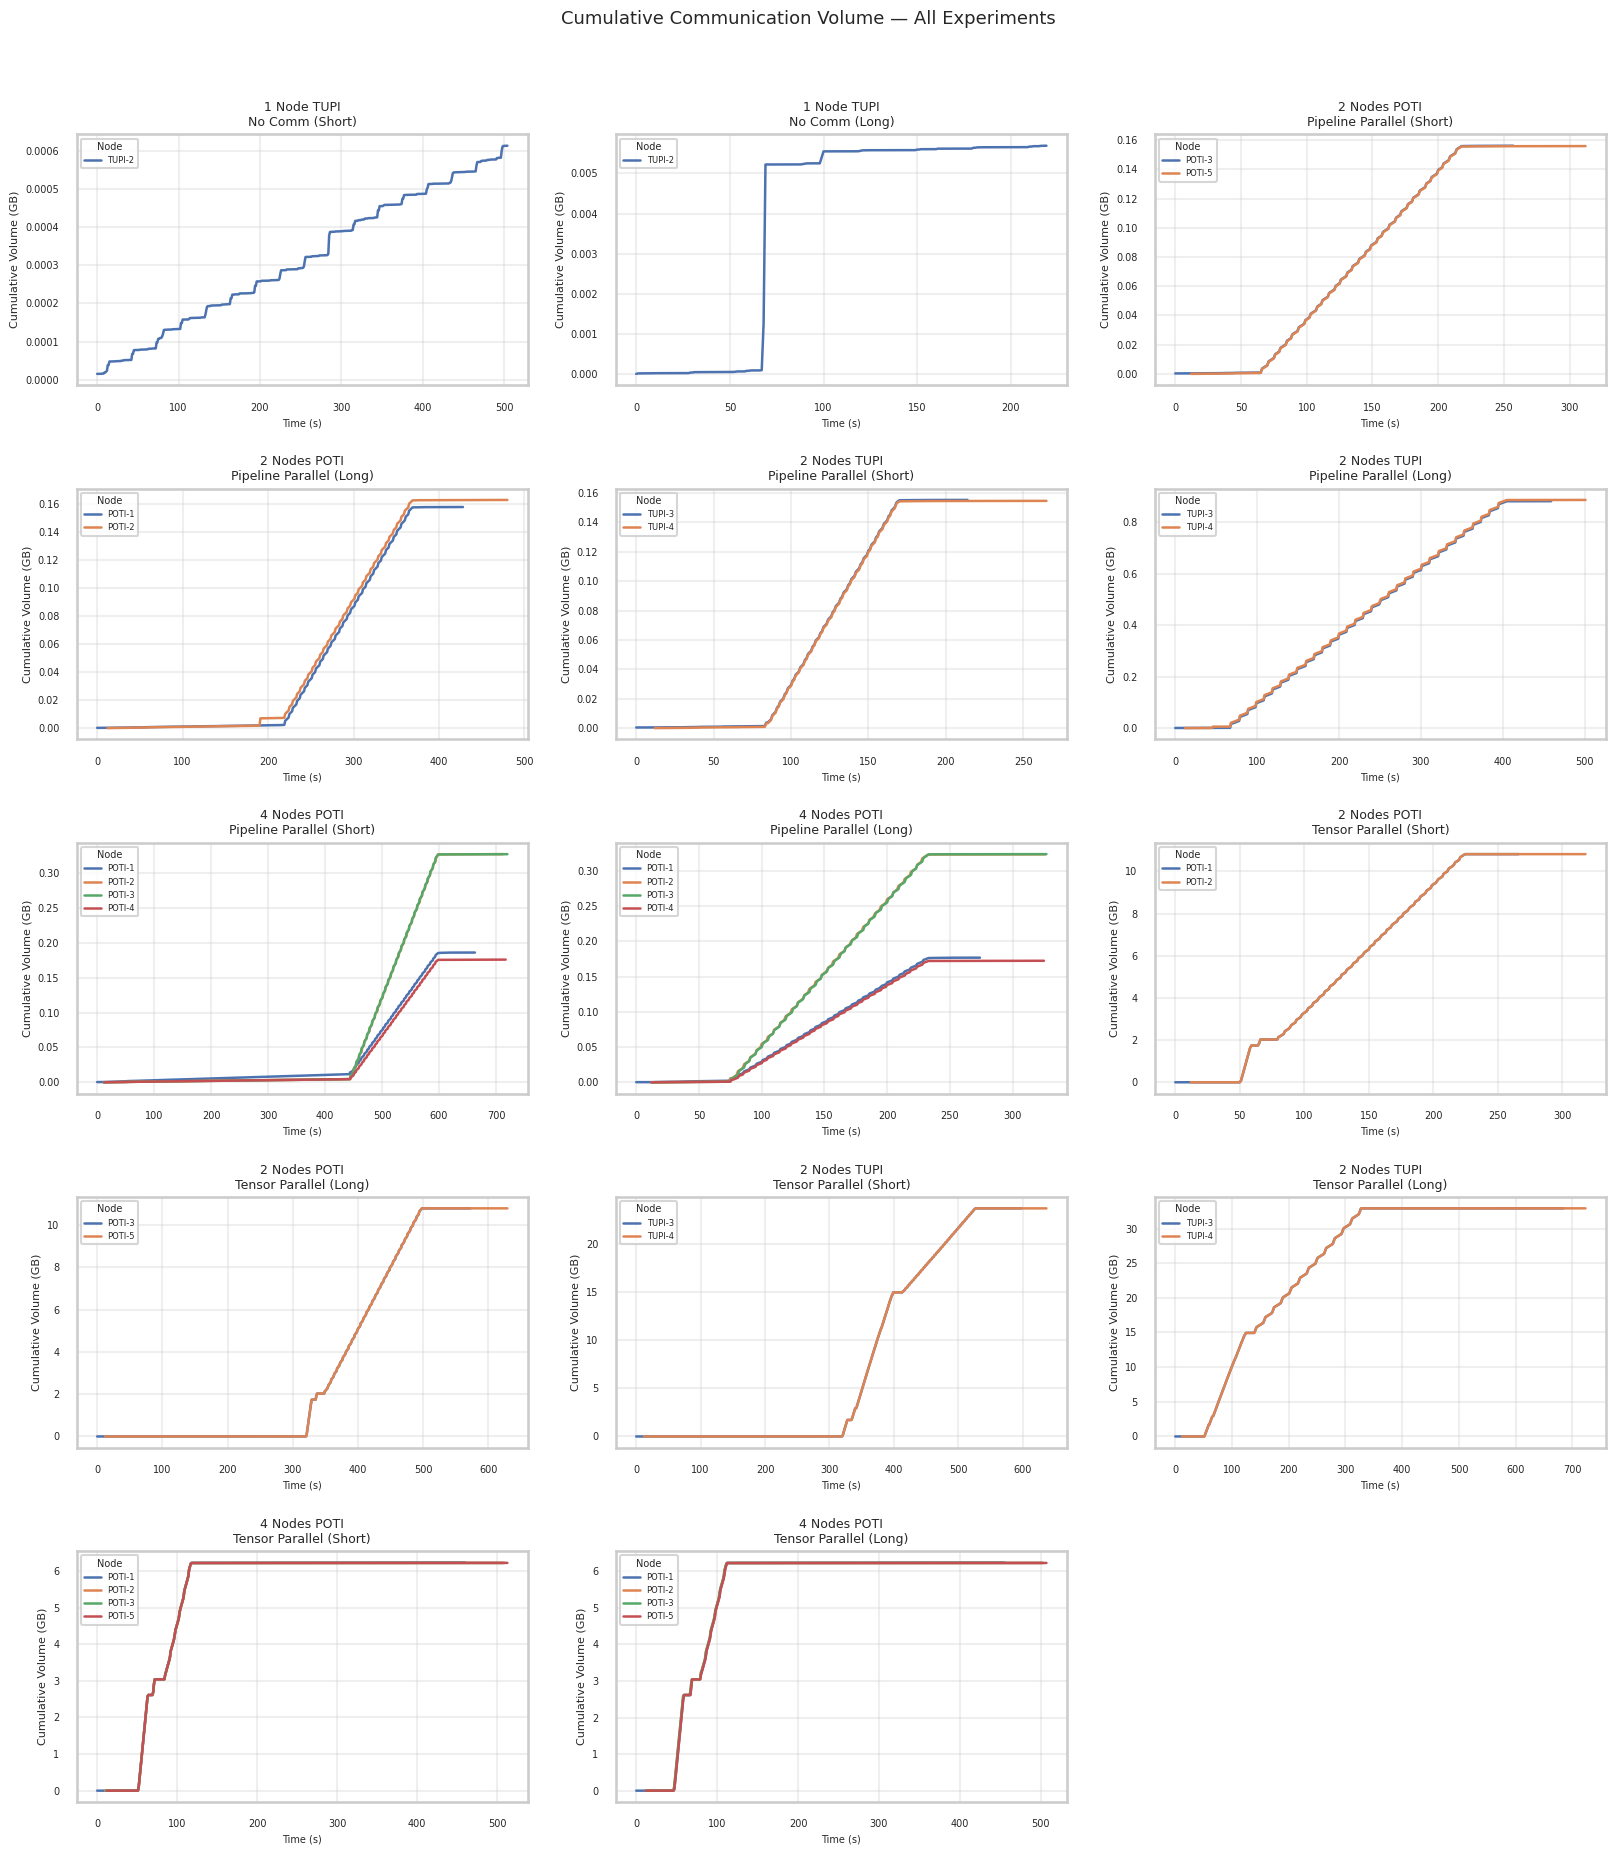

In [10]:
exp_names_sorted = sorted(ordered_experiments, key=get_experiment_type)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5.5 * n_cols, 3.8 * n_rows), squeeze=False)
axes_flat = axes.flatten()

for ax, exp_name in zip(axes_flat, exp_names_sorted):
    exp_df = network_ts_df[network_ts_df['experiment_name'] == exp_name].copy()
    per_second = second_level_node_df(exp_df).sort_values(['node_name', 'timestamp'])
    per_second['t'] = (per_second['timestamp'] - per_second['timestamp'].min()).dt.total_seconds()
    per_second['cumulative_GB'] = (
        per_second.groupby('node_name')['total_kB_s'].cumsum() / (1024 * 1024)
    )
    for node in sorted(per_second['node_name'].unique()):
        node_df = per_second[per_second['node_name'] == node]
        ax.plot(node_df['t'], node_df['cumulative_GB'], linewidth=1.8, label=format_node_name(node))
    ax.set_title(format_experiment_name(exp_name), fontsize=9)
    ax.set_xlabel('Time (s)', fontsize=7)
    ax.set_ylabel('Cumulative Volume (GB)', fontsize=8)
    ax.tick_params(labelsize=7)
    ax.grid(True, alpha=0.3)
    ax.legend(title='Node', fontsize=6, title_fontsize=7)

for ax in axes_flat[n_exp:]:
    ax.set_visible(False)

fig.suptitle('Cumulative Communication Volume — All Experiments', fontsize=13)
fig.tight_layout(rect=[0, 0, 1, 0.97])
save_fig(fig, 'cumulative_communication_grid.png')


## Communication Volume & Burstiness

Volume total de comunicação por experimento e burstiness (coeficiente de variação = std/mean).
Valores elevados de CV indicam comunicação concentrada em picos curtos e intensos.

Referências: JAGERMAN & MELAMED (1994); LUANGSOMBOON et al. (2024) arXiv:2401.00329.


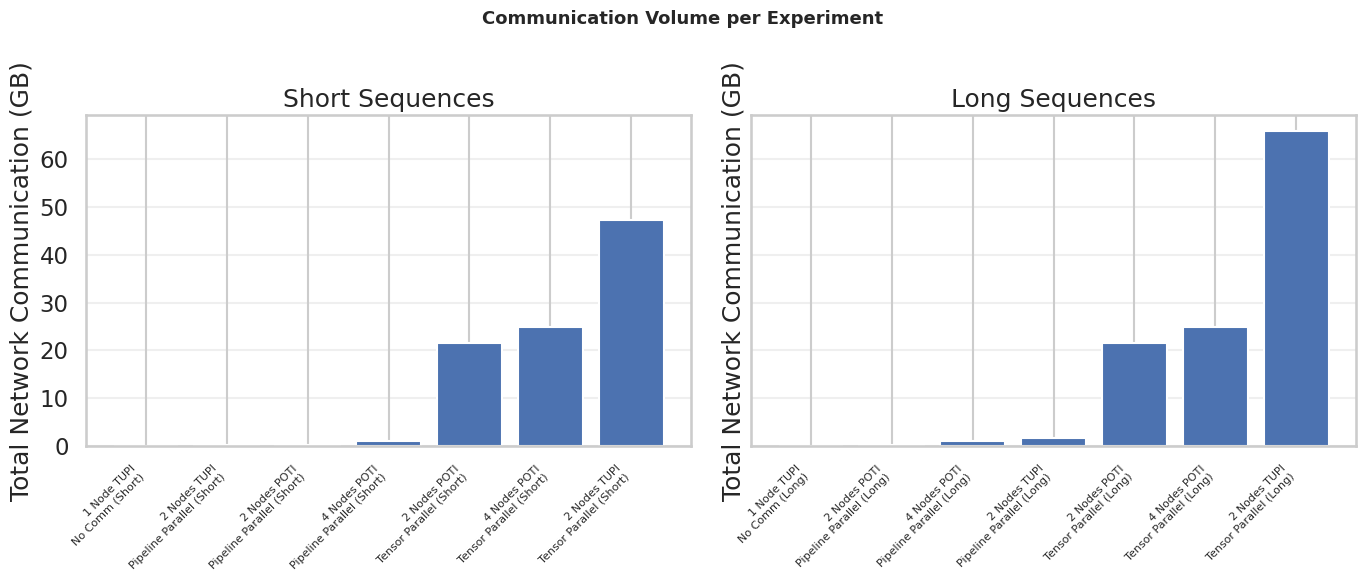

In [11]:
experiment_comm = network_ts_df.groupby('experiment_name')['total_kB_s'].sum().reset_index()
experiment_comm['total_GB'] = experiment_comm['total_kB_s'] / (1024 * 1024)
experiment_comm['experiment_label'] = experiment_comm['experiment_name'].apply(format_experiment_name)
experiment_comm['seqlen'] = experiment_comm['experiment_name'].apply(lambda x: parse_exp_name(x)['seqlen'])

fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

for ax, seqlen in zip(axes, ['short', 'long']):
    subset = experiment_comm[experiment_comm['seqlen'] == seqlen].sort_values('total_GB').reset_index(drop=True)
    if len(subset) > 0:
        ax.bar(range(len(subset)), subset['total_GB'])
        ax.set_xticks(range(len(subset)))
        ax.set_xticklabels(subset['experiment_label'], rotation=45, ha='right', fontsize=8)
        ax.set_ylabel('Total Network Communication (GB)')
        ax.set_title(f'{seqlen.capitalize()} Sequences')
        ax.grid(axis='y', alpha=0.3)

fig.suptitle('Communication Volume per Experiment', fontsize=13, fontweight='bold')
fig.tight_layout(rect=[0, 0, 1, 0.97])
save_fig(fig, 'communication_volume_bar.png')

### Communication Efficiency per Node

Normalizamos o volume total pelo número de nós, obtendo a comunicação média gerada por nó (`GB_per_node`).
Permite comparar experimentos com diferentes tamanhos de cluster em pé de igualdade.


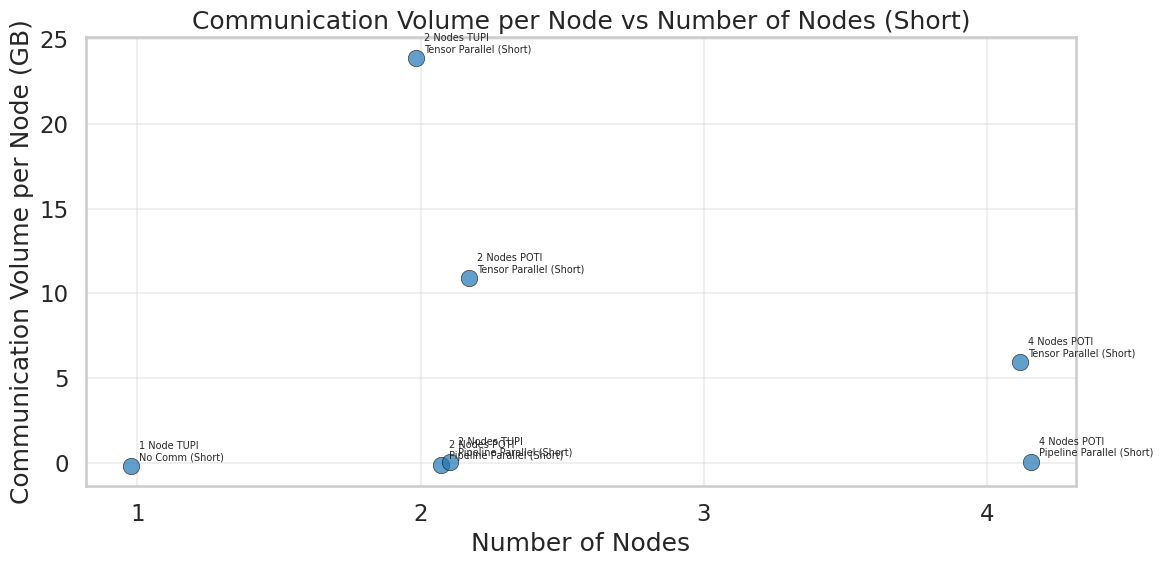

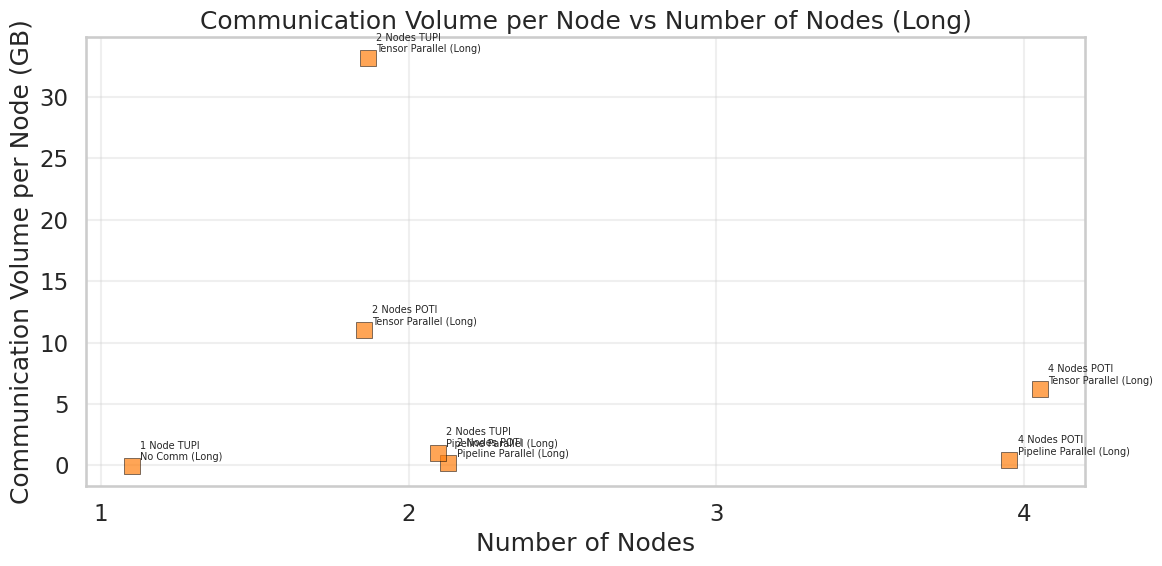

In [12]:
comm_df = (
    network_ts_df.groupby(['experiment_name', 'node_name'])['total_kB_s'].sum().reset_index()
    .groupby('experiment_name').agg(
        total_kB_s=('total_kB_s', 'sum'),
        n_nodes=('node_name', 'nunique'),
    ).reset_index()
)
comm_df['total_GB'] = comm_df['total_kB_s'] / (1024 * 1024)
comm_df['GB_per_node'] = comm_df['total_GB'] / comm_df['n_nodes']
comm_df['strategy'] = comm_df['experiment_name'].apply(lambda x: parse_exp_name(x)['parallelism'])
comm_df['seqlen'] = comm_df['experiment_name'].apply(lambda x: parse_exp_name(x)['seqlen'])
comm_df['experiment_label'] = comm_df['experiment_name'].apply(format_experiment_name)

rng = np.random.default_rng(42)
jitter_y = comm_df['GB_per_node'].std() * 0.03
comm_df['n_nodes_jitter'] = comm_df['n_nodes'] + rng.uniform(-0.18, 0.18, len(comm_df))
comm_df['gb_per_node_jitter'] = comm_df['GB_per_node'] + rng.uniform(-jitter_y, jitter_y, len(comm_df))

colors = {'short': '#1f77b4', 'long': '#ff7f0e'}
markers = {'short': 'o', 'long': 's'}

for seqlen_target in ['short', 'long']:
    subset_all = comm_df[comm_df['seqlen'] == seqlen_target]

    fig, ax = plt.subplots(figsize=(12, 6))
    ax.scatter(subset_all['n_nodes_jitter'], subset_all['gb_per_node_jitter'],
               c=colors[seqlen_target], marker=markers[seqlen_target], s=140, alpha=0.7,
               edgecolors='black', linewidth=0.5)

    for _, row in subset_all.iterrows():
        ax.annotate(row['experiment_label'], (row['n_nodes_jitter'], row['gb_per_node_jitter']),
                    textcoords='offset points', xytext=(6, 4), fontsize=7)

    ax.set_title(f'Communication Volume per Node vs Number of Nodes ({seqlen_target.capitalize()})')
    ax.set_xlabel('Number of Nodes')
    ax.set_ylabel('Communication Volume per Node (GB)')
    ax.set_xticks([1, 2, 3, 4])
    ax.grid(True, alpha=0.3)
    fig.tight_layout()
    save_fig(fig, f'communication_volume_scaling_scatter_{seqlen_target}.png')

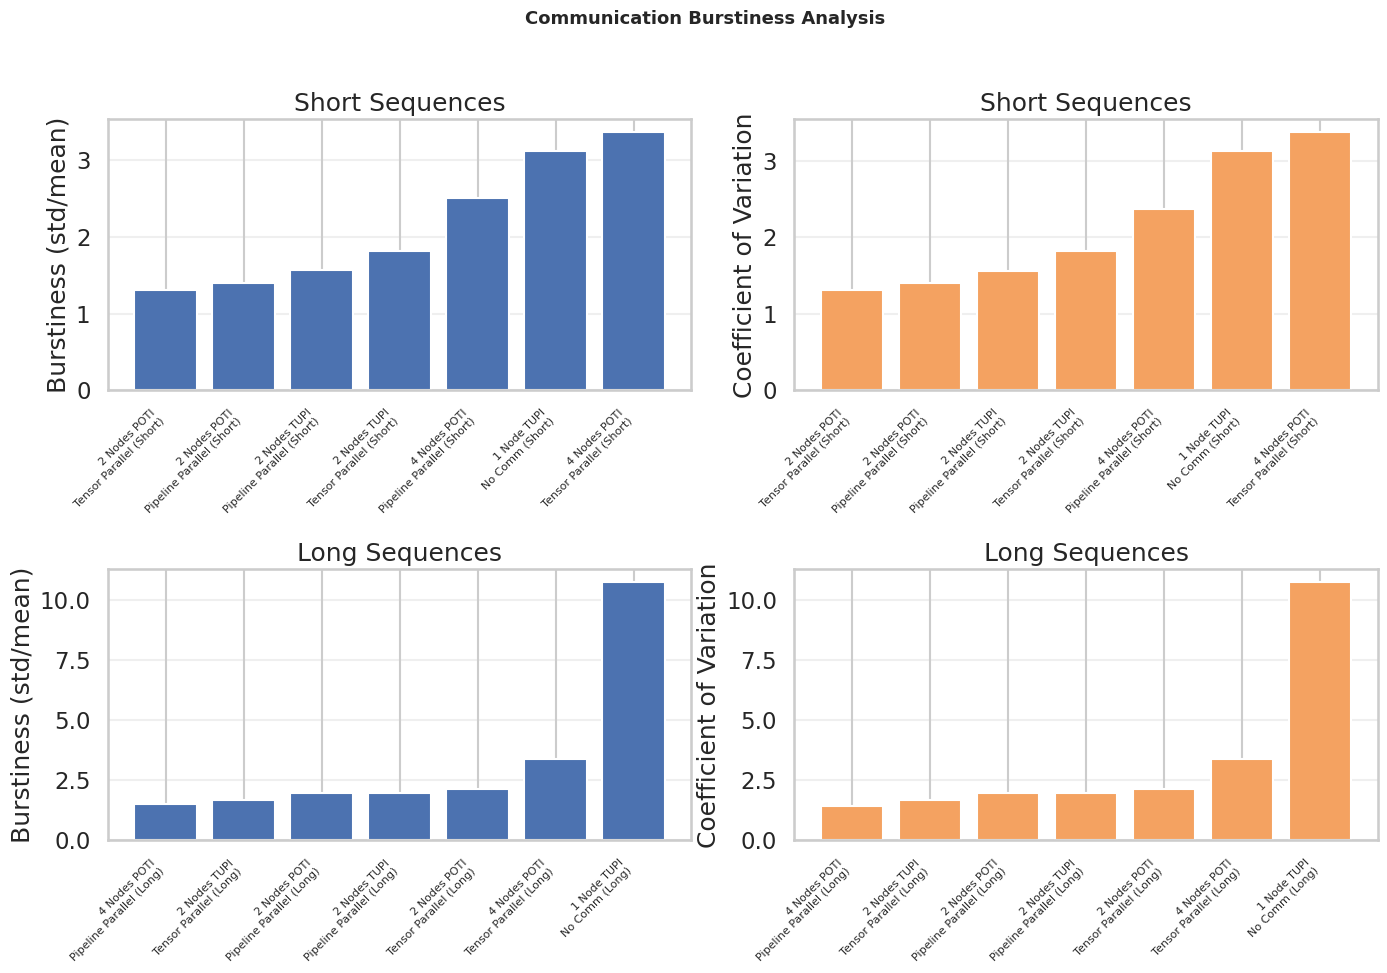

In [13]:
burstiness_df = (
    network_ts_df.groupby('experiment_name')['total_kB_s']
    .agg(lambda x: x.std() / (x.mean() + 1e-9))
    .reset_index()
)
burstiness_df.columns = ['experiment_name', 'burstiness_cv']
burstiness_df['experiment_label'] = burstiness_df['experiment_name'].apply(format_experiment_name)
burstiness_df['seqlen'] = burstiness_df['experiment_name'].apply(lambda x: parse_exp_name(x)['seqlen'])

node_stats = (
    network_ts_df.groupby(['experiment_name', 'node_name'])
    .agg(mean_kB_s=('total_kB_s', 'mean'), std_kB_s=('total_kB_s', 'std'))
    .reset_index()
)
node_stats['cv'] = node_stats['std_kB_s'] / (node_stats['mean_kB_s'] + 1e-9)
node_cv_df = (
    node_stats.groupby('experiment_name')['cv'].mean().reset_index()
)
node_cv_df.columns = ['experiment_name', 'node_cv']
node_cv_df['experiment_label'] = node_cv_df['experiment_name'].apply(format_experiment_name)
node_cv_df['seqlen'] = node_cv_df['experiment_name'].apply(lambda x: parse_exp_name(x)['seqlen'])

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for idx, seqlen in enumerate(['short', 'long']):
    burst_subset = burstiness_df[burstiness_df['seqlen'] == seqlen].sort_values('burstiness_cv').reset_index(drop=True)
    node_subset = node_cv_df[node_cv_df['seqlen'] == seqlen].sort_values('node_cv').reset_index(drop=True)
    
    ax = axes[idx, 0]
    if len(burst_subset) > 0:
        ax.bar(range(len(burst_subset)), burst_subset['burstiness_cv'])
        ax.set_xticks(range(len(burst_subset)))
        ax.set_xticklabels(burst_subset['experiment_label'], rotation=45, ha='right', fontsize=8)
        ax.set_ylabel('Burstiness (std/mean)')
        ax.set_title(f'{seqlen.capitalize()} Sequences')
        ax.grid(axis='y', alpha=0.3)
    
    ax = axes[idx, 1]
    if len(node_subset) > 0:
        ax.bar(range(len(node_subset)), node_subset['node_cv'], color='#f4a261')
        ax.set_xticks(range(len(node_subset)))
        ax.set_xticklabels(node_subset['experiment_label'], rotation=45, ha='right', fontsize=8)
        ax.set_ylabel('Coefficient of Variation')
        ax.set_title(f'{seqlen.capitalize()} Sequences')
        ax.grid(axis='y', alpha=0.3)

fig.suptitle('Communication Burstiness Analysis', fontsize=13, fontweight='bold')
fig.tight_layout(rect=[0, 0, 1, 0.97])
save_fig(fig, 'communication_burstiness.png')

## Communication Activity and Overhead

Em vez de medir apenas volume, esta seção mede **tempo**: por quanto da execução cada experimento
esteve efetivamente comunicando dados pela rede (acima do limiar `COMM_THRESHOLD`), versus quanto
tempo ficou em silêncio de rede (presumivelmente computando).


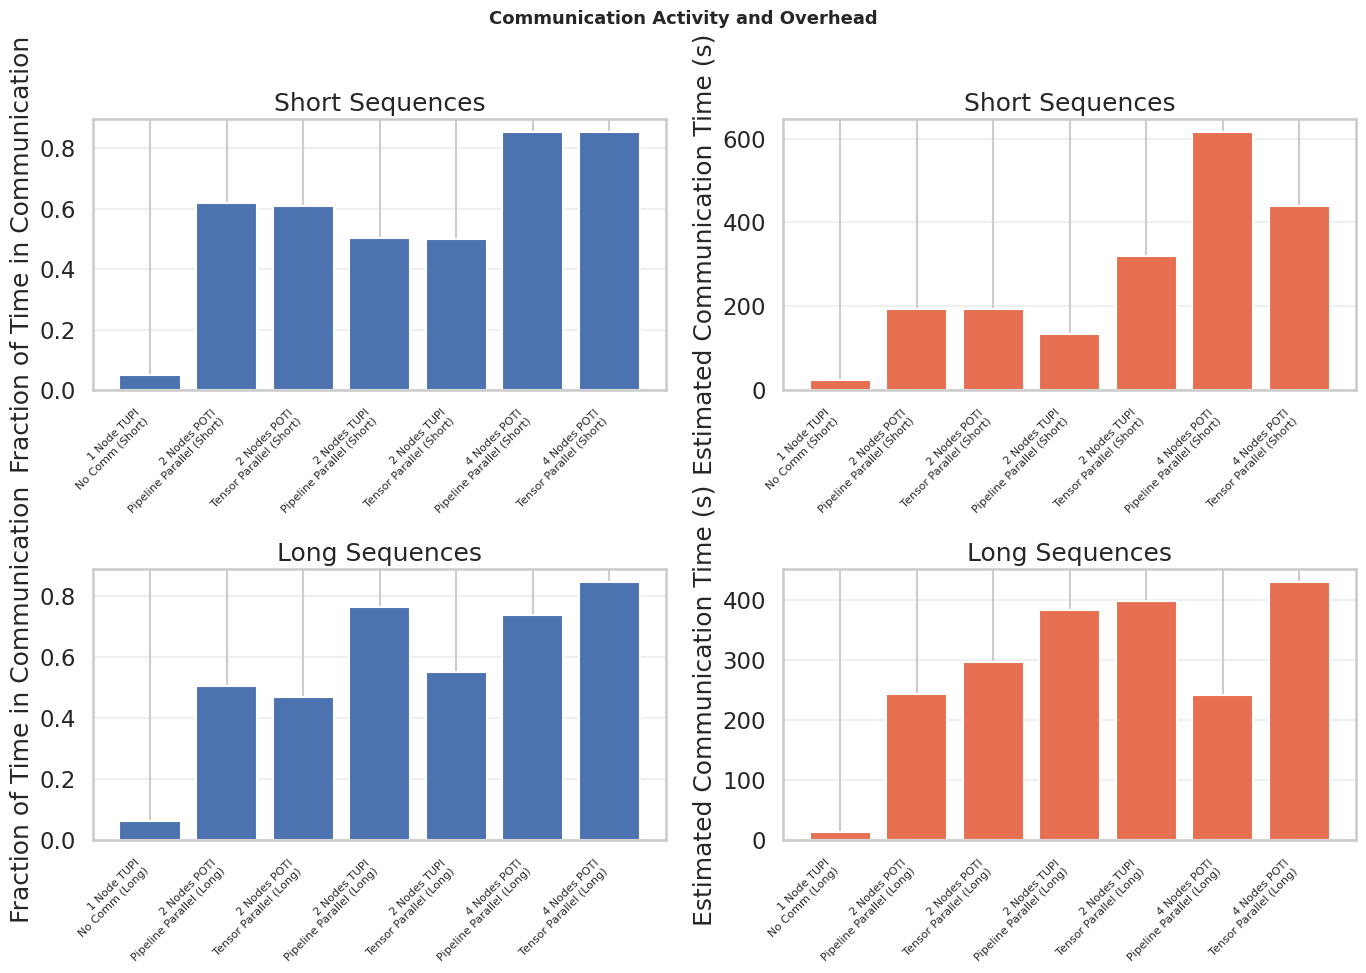

In [14]:
per_second = (
    network_ts_df.assign(timestamp=pd.to_datetime(network_ts_df['timestamp']))
    .groupby(['experiment_name', pd.Grouper(key='timestamp', freq='1s')])['total_kB_s']
    .sum().reset_index()
)
comm_time_df = (
    per_second.groupby('experiment_name').agg(
        comm_fraction=('total_kB_s', lambda x: (x > COMM_THRESHOLD).mean()),
        comm_active_seconds=('total_kB_s', lambda x: (x > COMM_THRESHOLD).sum()),
    ).reset_index()
)
comm_time_df['experiment_label'] = comm_time_df['experiment_name'].apply(format_experiment_name)
comm_time_df['seqlen'] = comm_time_df['experiment_name'].apply(lambda x: parse_exp_name(x)['seqlen'])

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for idx, seqlen in enumerate(['short', 'long']):
    subset = comm_time_df[comm_time_df['seqlen'] == seqlen].reset_index(drop=True)
    
    ax = axes[idx, 0]
    if len(subset) > 0:
        ax.bar(range(len(subset)), subset['comm_fraction'])
        ax.set_xticks(range(len(subset)))
        ax.set_xticklabels(subset['experiment_label'], rotation=45, ha='right', fontsize=8)
        ax.set_ylabel('Fraction of Time in Communication')
        ax.set_title(f'{seqlen.capitalize()} Sequences')
        ax.grid(axis='y', alpha=0.3)
    
    ax = axes[idx, 1]
    if len(subset) > 0:
        ax.bar(range(len(subset)), subset['comm_active_seconds'], color='#e76f51')
        ax.set_xticks(range(len(subset)))
        ax.set_xticklabels(subset['experiment_label'], rotation=45, ha='right', fontsize=8)
        ax.set_ylabel('Estimated Communication Time (s)')
        ax.set_title(f'{seqlen.capitalize()} Sequences')
        ax.grid(axis='y', alpha=0.3)

fig.suptitle('Communication Activity and Overhead', fontsize=13, fontweight='bold')
fig.tight_layout(rect=[0, 0, 1, 0.97])
save_fig(fig, 'communication_activity.png')

## Network Topology

Distribuição relativa do tráfego por nó, normalizada por experimento.
Identifica desbalanceamento entre nós dentro de cada estratégia de paralelismo.


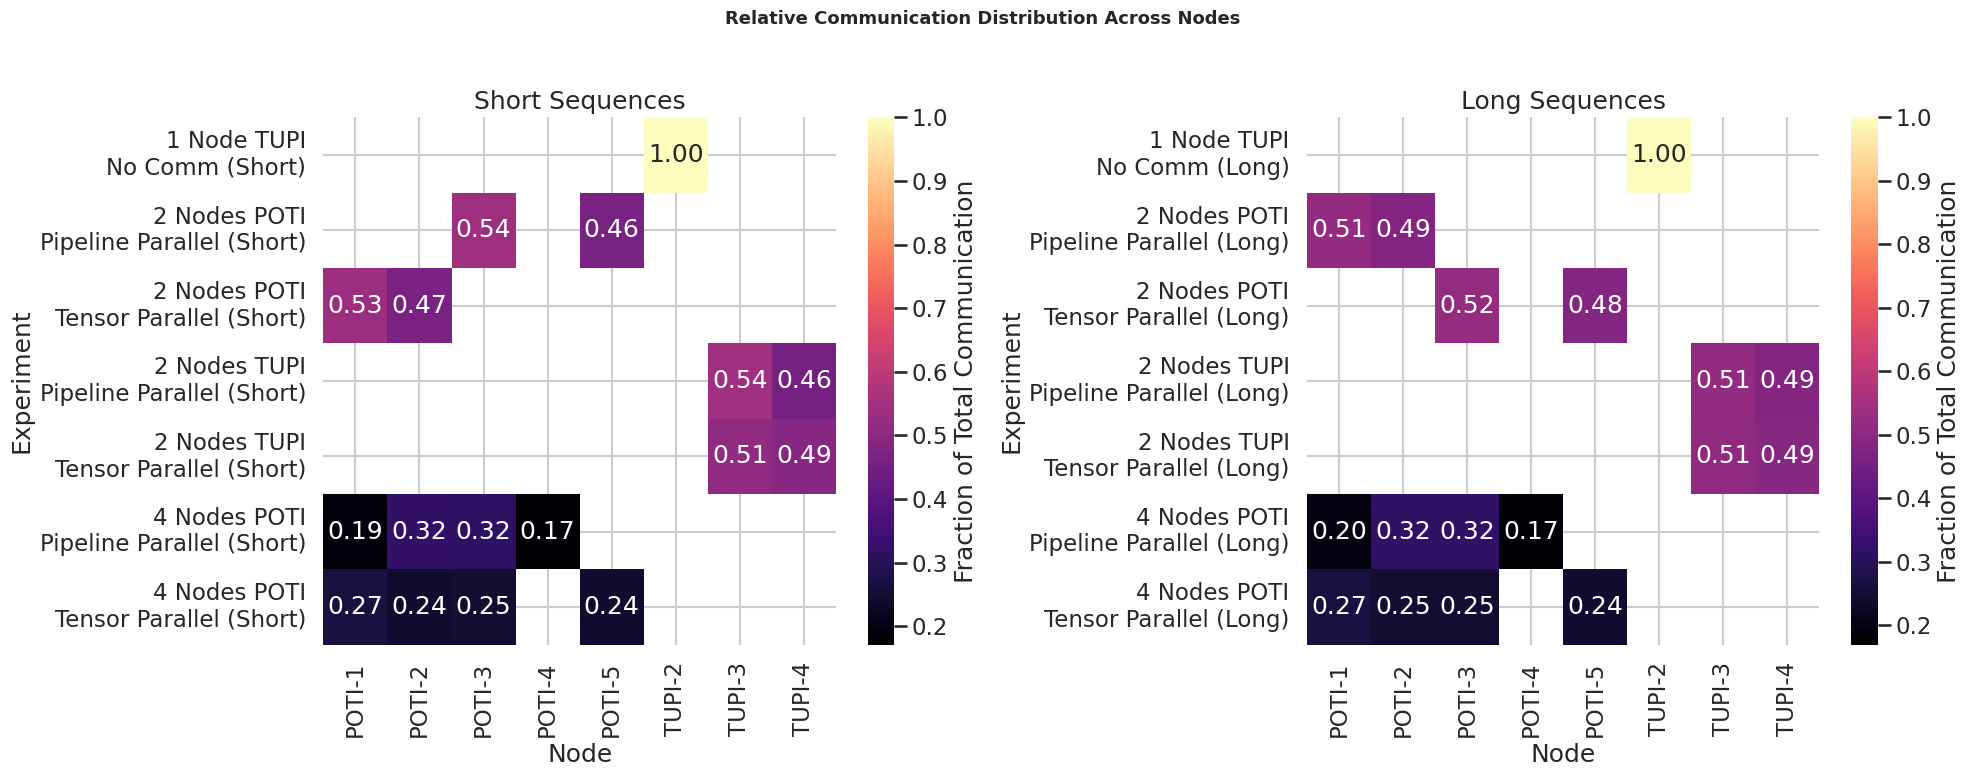

In [15]:
topology_data = (
    network_ts_df
    .assign(
        experiment_label=lambda d: d['experiment_name'].apply(format_experiment_name),
        node_label=lambda d: d['node_name'].apply(format_node_name),
        seqlen=lambda d: d['experiment_name'].apply(lambda x: parse_exp_name(x)['seqlen']),
    )
)

fig, axes = plt.subplots(1, 2, figsize=(20, 8))

for ax_idx, seqlen in enumerate(['short', 'long']):
    subset = topology_data[topology_data['seqlen'] == seqlen]
    
    topology_raw = (
        subset
        .groupby(['experiment_label', 'node_label'])['total_kB_s']
        .mean()
        .unstack()
    )
    topology_norm = topology_raw.div(topology_raw.sum(axis=1), axis=0)
    
    sns.heatmap(
        topology_norm, annot=True, fmt='.2f', cmap='magma',
        cbar_kws={'label': 'Fraction of Total Communication'}, ax=axes[ax_idx],
    )
    axes[ax_idx].set_title(f'{seqlen.capitalize()} Sequences')
    axes[ax_idx].set_xlabel('Node')
    axes[ax_idx].set_ylabel('Experiment')

fig.suptitle('Relative Communication Distribution Across Nodes', fontsize=13, fontweight='bold')
fig.tight_layout(rect=[0, 0, 1, 0.97])
save_fig(fig, 'network_topology_heatmap_normalized.png')

## Bottleneck Analysis

Tests whether communication intensity correlates with inference latency, and whether
latency degrades with cluster size and parallelism strategy.

**Hypothesis**: Higher communication volume/intensity correlates with higher latency.
Non-flat scaling lines (latency increasing with nodes) indicate a communication bottleneck.


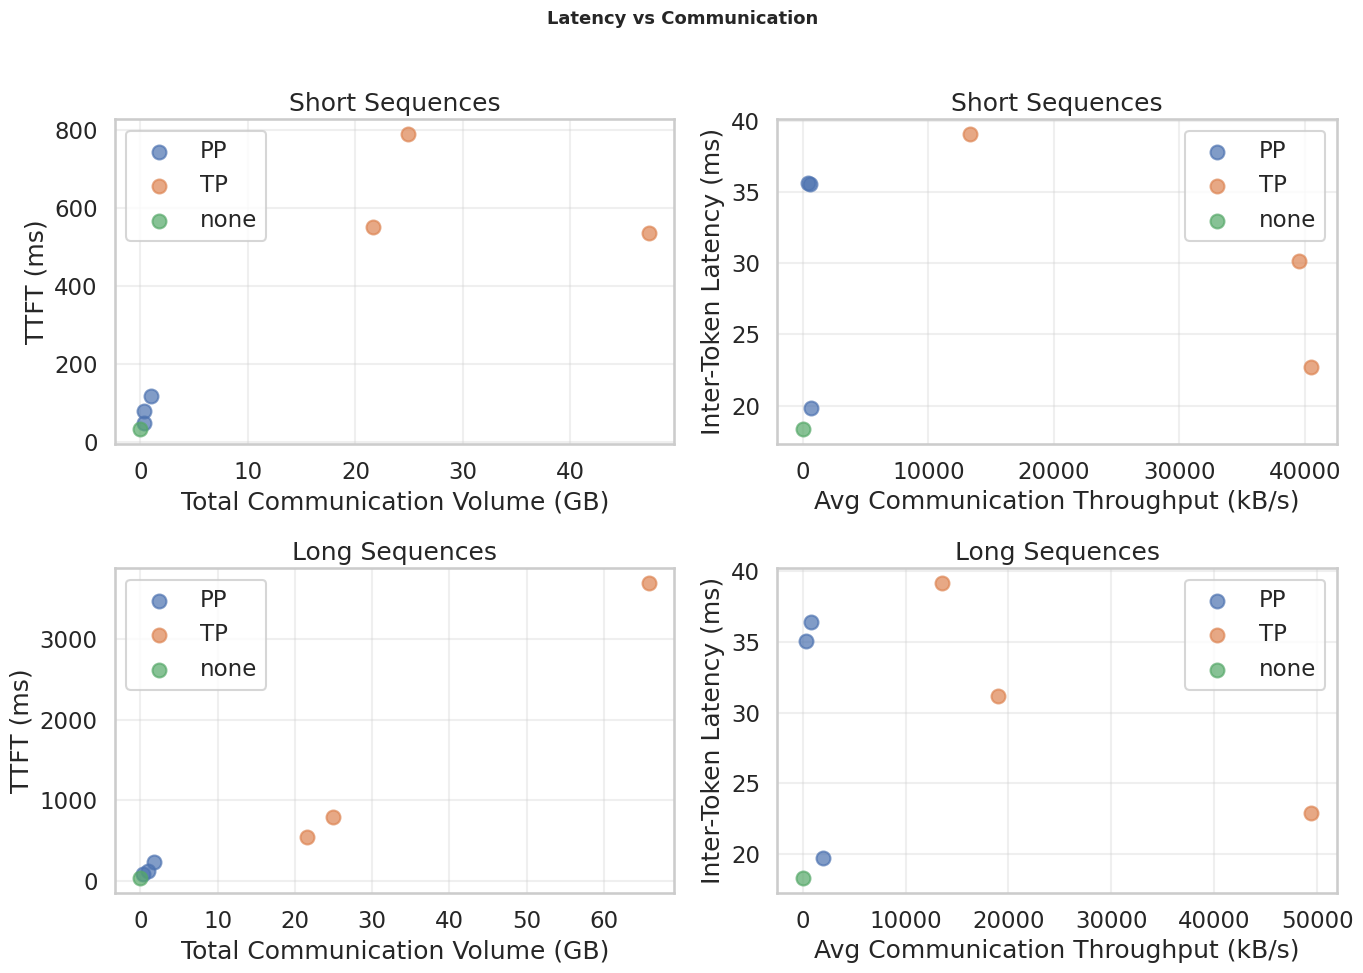

In [16]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for idx, seqlen in enumerate(['short', 'long']):
    ax = axes[idx, 0]
    valid = summary_df[summary_df['seqlen'] == seqlen].dropna(subset=['TTFT_avg_ms', 'total_volume_GB', 'parallelism'])
    if len(valid) > 0:
        for par in valid['parallelism'].unique():
            subset = valid[valid['parallelism'] == par]
            ax.scatter(subset['total_volume_GB'], subset['TTFT_avg_ms'], label=par, s=100, alpha=0.7)
    ax.set_xlabel('Total Communication Volume (GB)')
    ax.set_ylabel('TTFT (ms)')
    ax.set_title(f'{seqlen.capitalize()} Sequences')
    ax.legend()
    ax.grid(True, alpha=0.3)

    ax = axes[idx, 1]
    valid = summary_df[summary_df['seqlen'] == seqlen].dropna(subset=['inter_token_avg_ms', 'total_comm_avg_kB_s', 'parallelism'])
    if len(valid) > 0:
        for par in valid['parallelism'].unique():
            subset = valid[valid['parallelism'] == par]
            ax.scatter(subset['total_comm_avg_kB_s'], subset['inter_token_avg_ms'], label=par, s=100, alpha=0.7)
    ax.set_xlabel('Avg Communication Throughput (kB/s)')
    ax.set_ylabel('Inter-Token Latency (ms)')
    ax.set_title(f'{seqlen.capitalize()} Sequences')
    ax.legend()
    ax.grid(True, alpha=0.3)

fig.suptitle('Latency vs Communication', fontsize=13, fontweight='bold')
fig.tight_layout(rect=[0, 0, 1, 0.97])
save_fig(fig, 'latency_vs_communication.png')

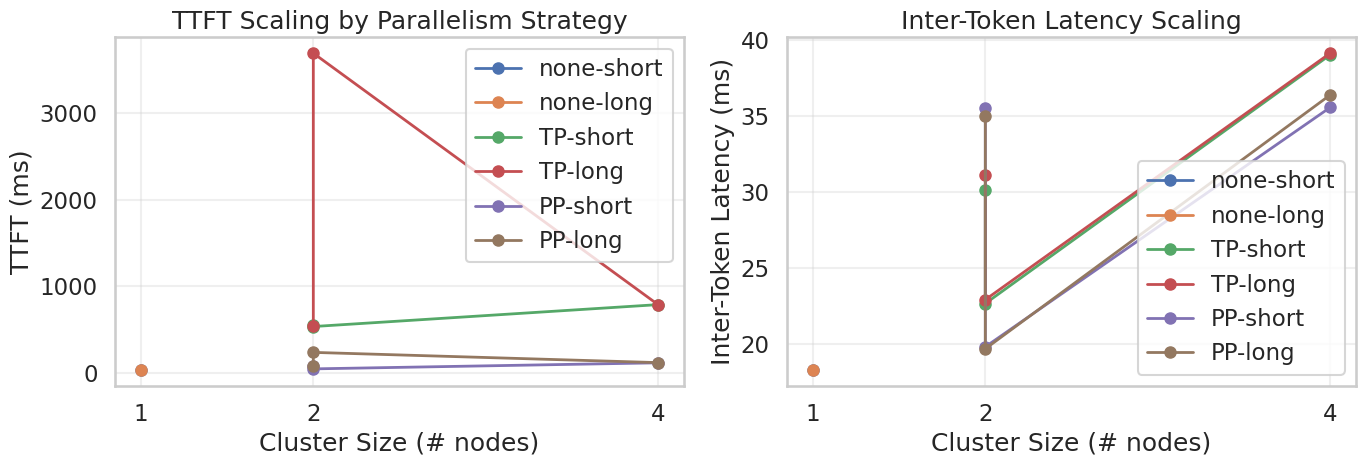

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, metric, ylabel, title in [
    (axes[0], 'TTFT_avg_ms', 'TTFT (ms)', 'TTFT Scaling by Parallelism Strategy'),
    (axes[1], 'inter_token_avg_ms', 'Inter-Token Latency (ms)', 'Inter-Token Latency Scaling'),
]:
    valid = summary_df.dropna(subset=[metric, 'cluster_size', 'parallelism', 'seqlen'])
    for par in ['none', 'TP', 'PP']:
        for seqlen in ['short', 'long']:
            subset = valid[
                (valid['parallelism'] == par) & (valid['seqlen'] == seqlen)
            ].sort_values('cluster_size')
            if len(subset) > 0:
                ax.plot(subset['cluster_size'], subset[metric], marker='o',
                        label=f'{par}-{seqlen}', linewidth=2, markersize=8)
    ax.set_xlabel('Cluster Size (# nodes)')
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.set_xticks([1, 2, 4])
    ax.legend()
    ax.grid(True, alpha=0.3)

fig.tight_layout()
save_fig(fig, 'scaling_trends.png')


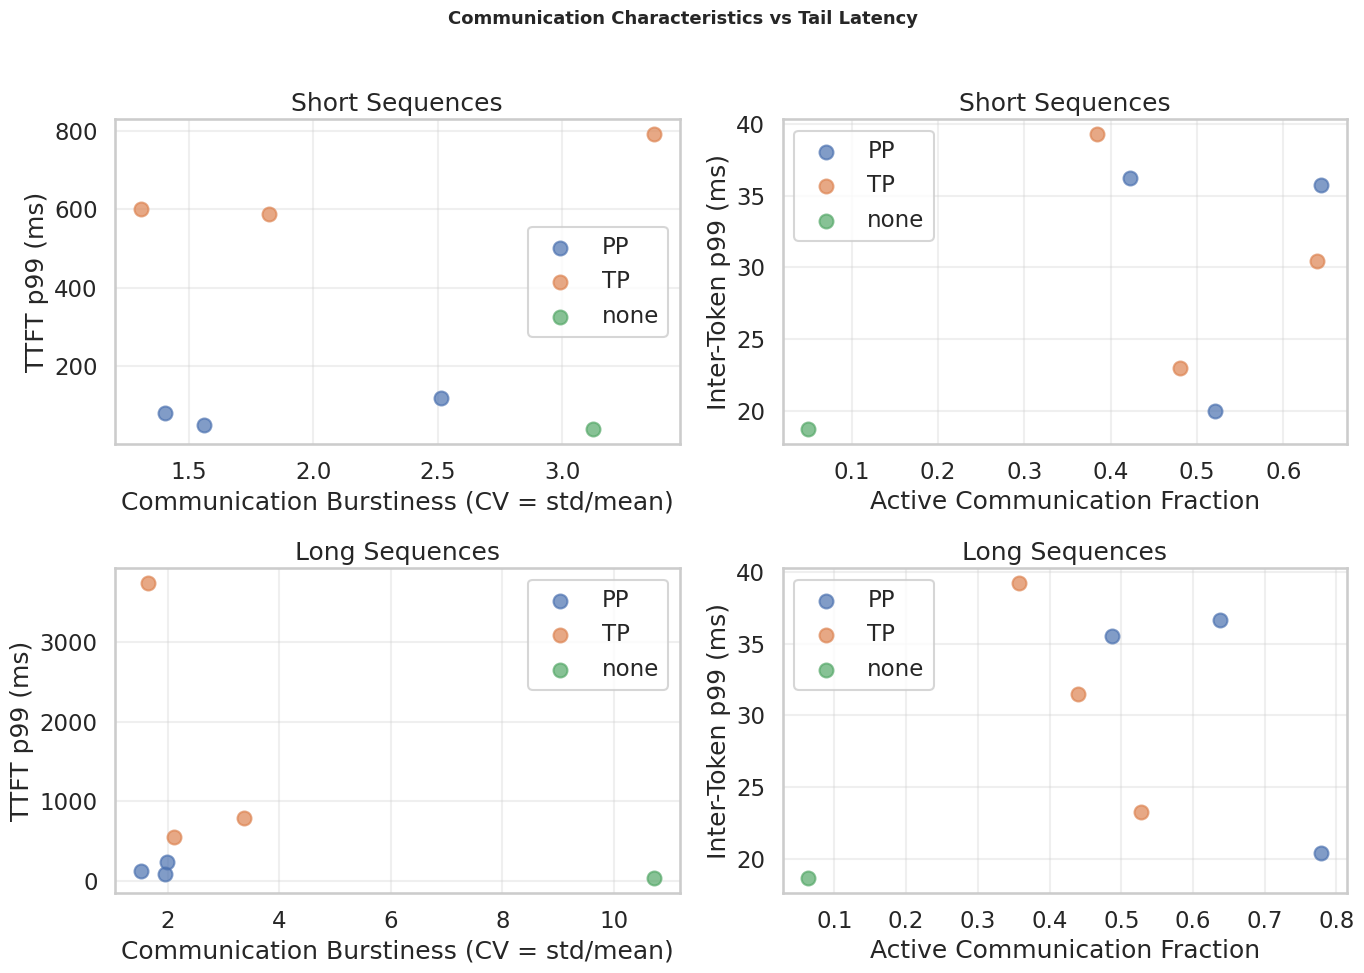

In [19]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for idx, seqlen in enumerate(['short', 'long']):
    ax = axes[idx, 0]
    valid = summary_df[summary_df['seqlen'] == seqlen].dropna(subset=['burstiness_cv', 'TTFT_p99_ms', 'parallelism'])
    if len(valid) > 0:
        for par in valid['parallelism'].unique():
            subset = valid[valid['parallelism'] == par]
            ax.scatter(subset['burstiness_cv'], subset['TTFT_p99_ms'], label=par, s=100, alpha=0.7)
    ax.set_xlabel('Communication Burstiness (CV = std/mean)')
    ax.set_ylabel('TTFT p99 (ms)')
    ax.set_title(f'{seqlen.capitalize()} Sequences')
    ax.legend()
    ax.grid(True, alpha=0.3)

    ax = axes[idx, 1]
    valid = summary_df[summary_df['seqlen'] == seqlen].dropna(subset=['active_comm_fraction', 'inter_token_p99_ms', 'parallelism'])
    if len(valid) > 0:
        for par in valid['parallelism'].unique():
            subset = valid[valid['parallelism'] == par]
            ax.scatter(subset['active_comm_fraction'], subset['inter_token_p99_ms'], label=par, s=100, alpha=0.7)
    ax.set_xlabel('Active Communication Fraction')
    ax.set_ylabel('Inter-Token p99 (ms)')
    ax.set_title(f'{seqlen.capitalize()} Sequences')
    ax.legend()
    ax.grid(True, alpha=0.3)

fig.suptitle('Communication Characteristics vs Tail Latency', fontsize=13, fontweight='bold')
fig.tight_layout(rect=[0, 0, 1, 0.97])
save_fig(fig, 'burstiness_vs_tail_latency.png')

## Summary


In [20]:
df = summary_df
n1 = df[df['cluster_size'] == 1]

print('=' * 60)
print('BOTTLENECK ANALYSIS SUMMARY')
print('=' * 60)

if len(n1) > 0:
    print(f'\nN1 Baseline (avg across variants):')
    print(f'  TTFT:        {n1["TTFT_avg_ms"].mean():.2f} ms')
    print(f'  Inter-token: {n1["inter_token_avg_ms"].mean():.2f} ms')
    print(f'  Comm volume: {n1["total_volume_GB"].mean():.3f} GB')

for csize in [2, 4]:
    multi = df[df['cluster_size'] == csize]
    if len(multi) > 0:
        ot = multi['TTFT_overhead_pct'].dropna()
        oi = multi['inter_token_overhead_pct'].dropna()
        print(f'\nN{csize} vs N1:')
        if len(ot) > 0:
            print(f'  TTFT overhead:        {ot.mean():.1f}% (range: {ot.min():.1f}\u2013{ot.max():.1f}%)')
        if len(oi) > 0:
            print(f'  Inter-token overhead: {oi.mean():.1f}%')
        print(f'  Avg comm volume: {multi["total_volume_GB"].mean():.2f} GB')

print('\nCorrelations:')
c = df.dropna(subset=['TTFT_avg_ms', 'total_comm_avg_kB_s'])
if len(c) > 1:
    print(f'  TTFT vs avg comm throughput: {c["TTFT_avg_ms"].corr(c["total_comm_avg_kB_s"]):.3f}')
c = df.dropna(subset=['inter_token_avg_ms', 'total_volume_GB'])
if len(c) > 1:
    print(f'  Inter-token vs comm volume:  {c["inter_token_avg_ms"].corr(c["total_volume_GB"]):.3f}')

print(f'\nFigures saved to: {IMAGES_DIR}')
print(f'CSVs saved to:    {OUTPUT_DIR}')


BOTTLENECK ANALYSIS SUMMARY

N1 Baseline (avg across variants):
  TTFT:        32.08 ms
  Inter-token: 18.31 ms
  Comm volume: 0.003 GB

N2 vs N1:
  TTFT overhead:        3431.5% (range: 47.7–11466.5%)
  Inter-token overhead: 16.3%
  Avg comm volume: 19.89 GB

N4 vs N1:
  Avg comm volume: 12.96 GB

Correlations:
  TTFT vs avg comm throughput: 0.734
  Inter-token vs comm volume:  -0.042

Figures saved to: ../data/figures/04_network
CSVs saved to:    ../data/processed
